In [1]:
# %matplotlib notebook
%matplotlib inline 
# 在单元格内部直接显示图像，而不会弹出新窗口

# 机器学习入门实验
## 课程目标
1. 熟悉机器学习开发环境
1. 查阅常用数据集说明
1. 学习数据读写方法以及数据可视化方法

## 数据集
本次实验我们将认识鸢尾花卉数据集（Iris flower dataset），糖尿病数据集（Diabetes dataset），以及西瓜数据集2.0/3.0。

### 鸢尾花卉数据集（Iris flower dataset）
其数据集包含了150个样本，都属于鸢尾属下的3个亚属，分别是山鸢尾（学名：Iris setosa）、变色鸢尾（学名：Iris versicolor）和维吉尼亚鸢尾。每个样本都包含4项特征，即花萼和花瓣的长度和宽度，它们可用于样本的定量分析。


| 山鸢尾（学名：Iris setosa） | 变色鸢尾（学名：Iris versicolor） | 维吉尼亚鸢尾（学名：Iris virginica）  |
|:--:|:--:|:--:|
| 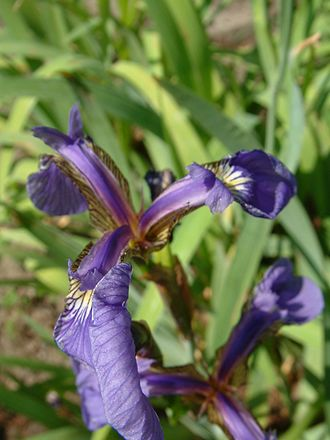 | 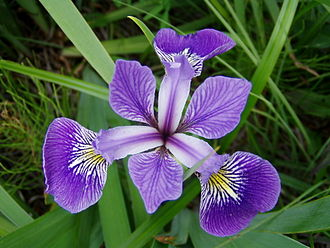 | 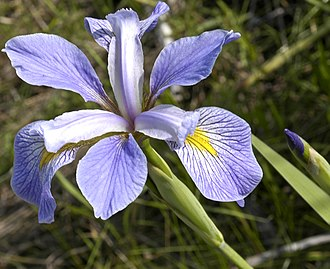 |


scikit-learn附带了一些小型的标准数据集（包括Iris），不需要从外部网站下载任何文件。

In [9]:
# 导入所需的库
import numpy as np
# 用于数值计算和数组操作
import pandas as pd
# 用于数据分析和数据处理
import matplotlib.pyplot as plt
# 用于数据可视化
from sklearn import datasets
# 加载 scikit-learn 提供的标准数据集

# Load Iris dataset
iris = datasets.load_iris()
# print(iris)
X = iris.data # Feature matrix
y = iris.target # Label vector
feature_names = iris.feature_names # Feature names
target_names = iris.target_names # label names

# Transform the data into DataFrame format for easy viewing and manipulation.
df = pd.DataFrame(X, columns=feature_names)
# 创建 Pandas 数据框，列名对应特征名称
df['target'] = y
df['target_name'] = df['target'].apply(lambda x: target_names[x])

# Inspect the basic information of the dataset.
print("=== 鸢尾花数据集前5行 ===")
print(df.head())
print("\n=== 鸢尾花数据集统计信息 ===")
print(df.describe())
print("\n=== 各类别样本数量 ===")
print(df['target_name'].value_counts())
print("\n=== 数据集维度 ===")
print(f"特征矩阵维度：{X.shape}，标签向量维度：{y.shape}")
print("\n=== 特征名称 ===")
print(feature_names)

=== 鸢尾花数据集前5行 ===
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   target target_name  
0       0      setosa  
1       0      setosa  
2       0      setosa  
3       0      setosa  
4       0      setosa  

=== 鸢尾花数据集统计信息 ===
       sepal length (cm)  sepal width (cm)  petal length (cm)  \
count         150.000000        150.000000         150.000000   
mean            5.843333          3.057333           3.758000   
std             0.828066          0.435866           1.765298   
min             4.300000          2.000000           1.000000   
25%             5.

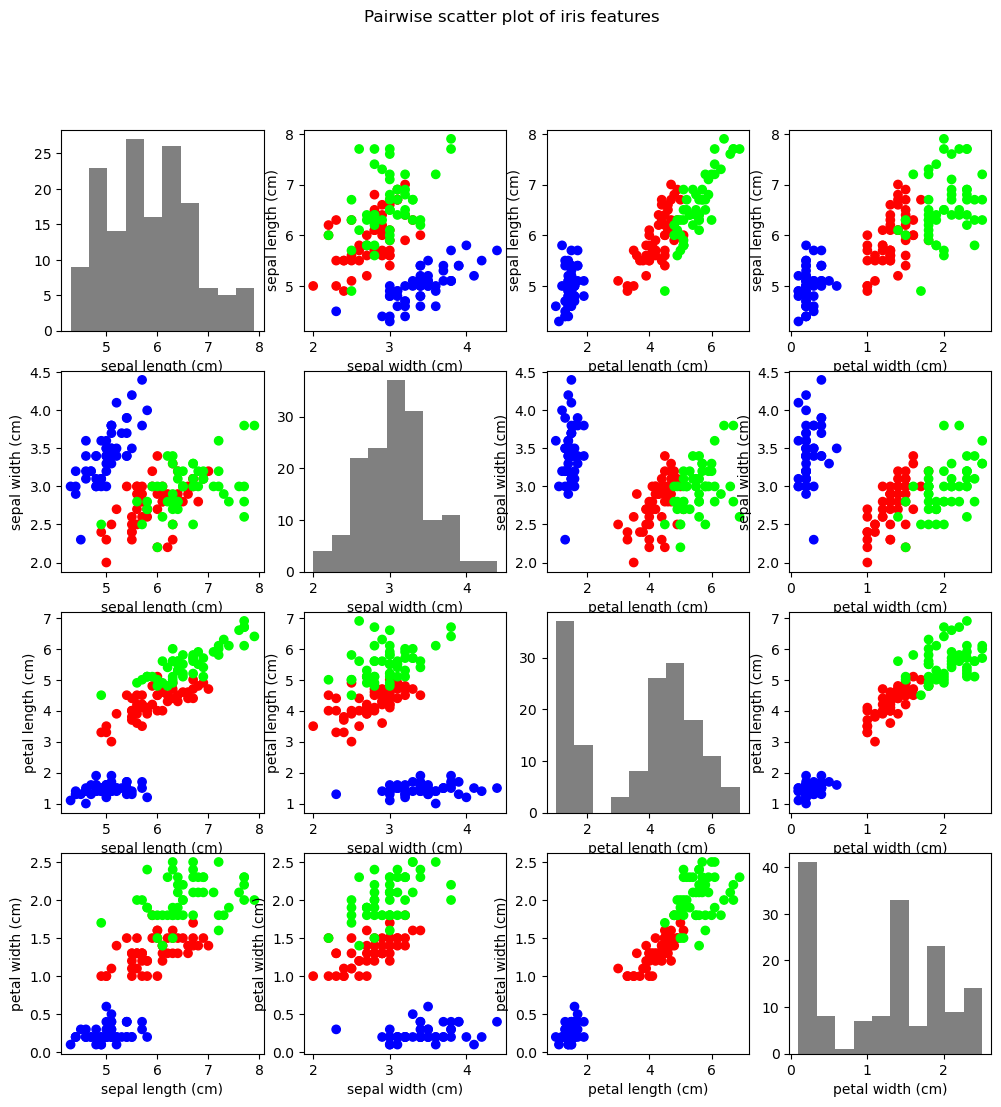

In [3]:
# 绘制两两特征之间的散点图，用不同颜色区分不同类别的花
plt.figure(figsize=(12, 12))
# 创建 12x12 英寸的画布
for i in range(4):
    for j in range(4):
        plt.subplot(4, 4, i * 4 + j + 1)
        # 创建 4x4 的子图
        if i == j:
            plt.hist(df[feature_names[i]], color='gray')
            # 画直方图
            plt.xlabel(feature_names[i])
        else:
            plt.scatter(df[feature_names[j]], df[feature_names[i]], c=df['target'], cmap='brg')
            # 绘制散点图，颜色表示类别。
            plt.xlabel(feature_names[j])
            plt.ylabel(feature_names[i])
plt.suptitle('Pairwise scatter plot of iris features')
plt.show()

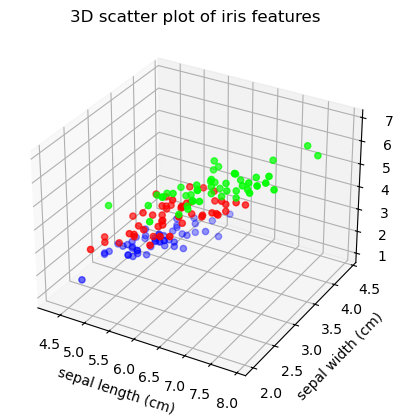

In [4]:
# 绘制三维散点图，选择三个特征进行可视化
from mpl_toolkits.mplot3d import Axes3D
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.scatter(df['sepal length (cm)'], df['sepal width (cm)'], df['petal length (cm)'], c=df['target'], cmap='brg')
ax.set_xlabel('sepal length (cm)')
ax.set_ylabel('sepal width (cm)')
ax.set_zlabel('petal length (cm)')
ax.set_title('3D scatter plot of iris features')
plt.show()

In [5]:
# feature_names

### 糖尿病数据集（Diabetes dataset）
Diabetes dataset是一个用于回归分析的数据集，它包含了442个样本和10个特征。这些特征是年龄、性别、体重指数、平均血压和6个血清测量。目标变量是一年后疾病进展的定量指标（progression）。这个数据集是从Framingham心脏研究中的442名糖尿病患者中提取的。

=== 糖尿病数据集前5行 ===
        age       sex       bmi        bp        s1        s2        s3  \
0  0.038076  0.050680  0.061696  0.021872 -0.044223 -0.034821 -0.043401   
1 -0.001882 -0.044642 -0.051474 -0.026328 -0.008449 -0.019163  0.074412   
2  0.085299  0.050680  0.044451 -0.005670 -0.045599 -0.034194 -0.032356   
3 -0.089063 -0.044642 -0.011595 -0.036656  0.012191  0.024991 -0.036038   
4  0.005383 -0.044642 -0.036385  0.021872  0.003935  0.015596  0.008142   

         s4        s5        s6  target  
0 -0.002592  0.019907 -0.017646   151.0  
1 -0.039493 -0.068332 -0.092204    75.0  
2 -0.002592  0.002861 -0.025930   141.0  
3  0.034309  0.022688 -0.009362   206.0  
4 -0.002592 -0.031988 -0.046641   135.0  

=== 糖尿病数据集统计信息 ===
                age           sex           bmi            bp            s1  \
count  4.420000e+02  4.420000e+02  4.420000e+02  4.420000e+02  4.420000e+02   
mean  -2.511817e-19  1.230790e-17 -2.245564e-16 -4.797570e-17 -1.381499e-17   
std    4.761905e-02  4

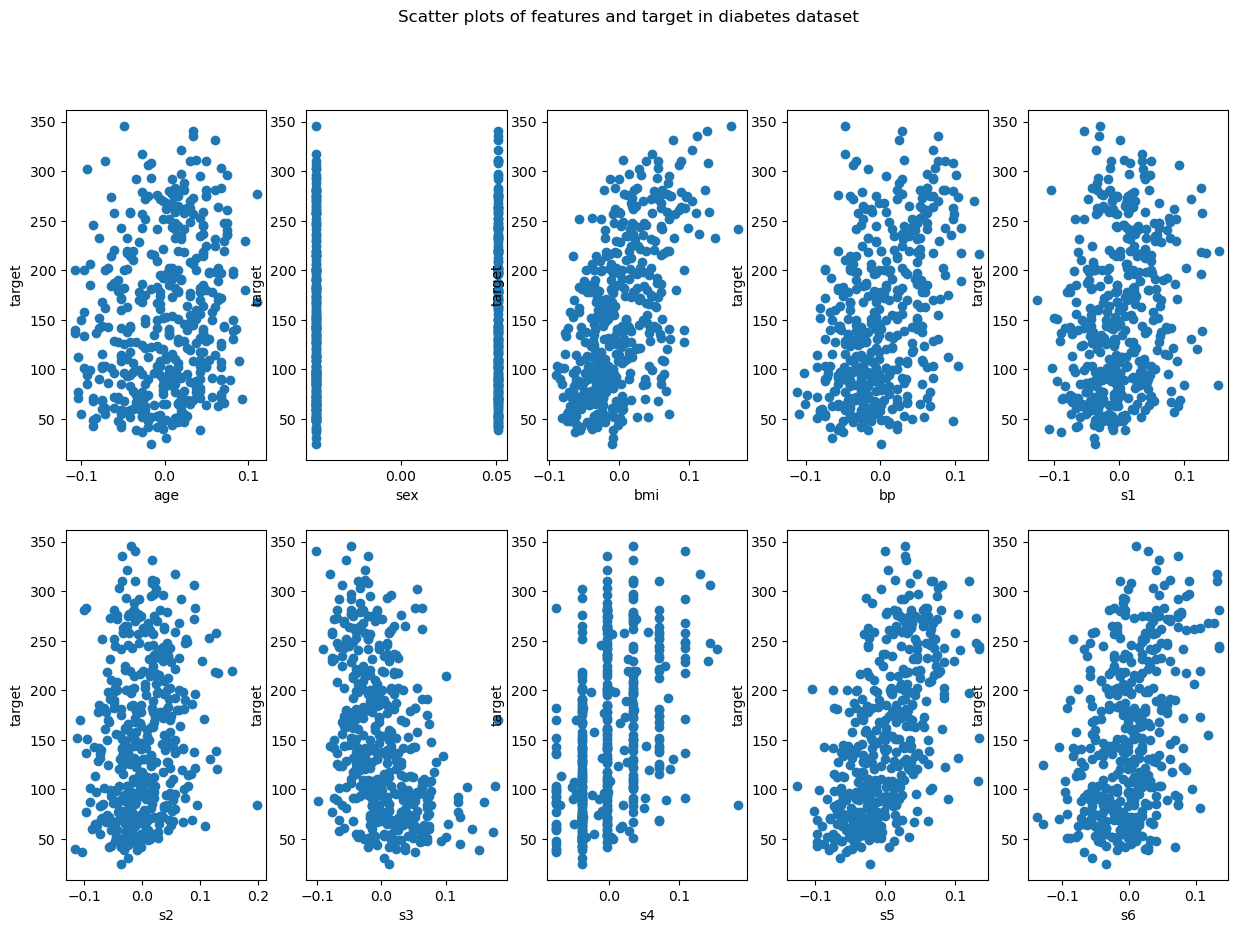

In [10]:
# 导入所需的库
import numpy as np
import matplotlib.pyplot as plt
from sklearn import datasets

# 加载 diabetes dataset
diabetes = datasets.load_diabetes()

# 获取特征和标签
X = diabetes.data
y = diabetes.target
feature_names_dia = diabetes.feature_names  # 特征名称

# 转换为DataFrame
df_dia = pd.DataFrame(X, columns=feature_names_dia)
df_dia['target'] = y

# 查看基本信息
print("=== 糖尿病数据集前5行 ===")
print(df_dia.head())
print("\n=== 糖尿病数据集统计信息 ===")
print(df_dia.describe())
print("\n=== 数据集维度 ===")
print(f"特征矩阵维度：{X.shape}，标签向量维度：{y.shape}")
print("\n=== 特征名称 ===")
print(feature_names_dia)

# 绘制训练集中每个特征与标签的散点图
plt.figure(figsize=(15, 10))
# 创建 15x10 英寸的画布
for i in range(10):
    plt.subplot(2, 5, i+1)
    # 创建 2 行 5 列的子图
    plt.scatter(X[:, i], y)
    # 绘制每个特征与目标值的散点图
    plt.xlabel(diabetes.feature_names[i])
    plt.ylabel('target')
plt.suptitle('Scatter plots of features and target in diabetes dataset')
plt.show()

=== 线性回归模型评估结果 ===
均方误差（MSE）：2821.75
决定系数（R²）：0.48
模型系数：[  29.25401303 -261.7064691   546.29972304  388.39834056 -901.95966819
  506.76324136  121.15435079  288.03526689  659.26895081   41.37670105]


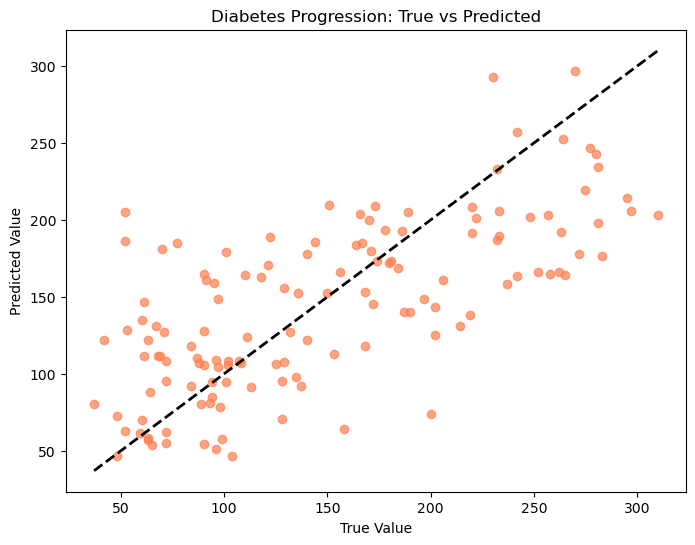

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

# 划分训练集和测试集（7:3）
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# 训练线性回归模型
lr = LinearRegression()
lr.fit(X_train, y_train)

# 预测并评估模型
y_pred = lr.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("=== 线性回归模型评估结果 ===")
print(f"均方误差(MSE):{mse:.2f}")
print(f"决定系数(R²):{r2:.2f}")
print(f"模型系数：{lr.coef_}")

# 绘制预测值与真实值的散点图
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, color='coral', alpha=0.7)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2)
plt.xlabel('True Value')
plt.ylabel('Predicted Value')
plt.title('Diabetes Progression: True vs Predicted')
plt.show()

## 西瓜数据集


In [12]:
# 西瓜数据集3.0特征：色泽、根蒂、敲声、纹理、脐部、触感、密度、含糖率，标签：好瓜
data_watermelon3 = {
    '编号': [1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17],
    '色泽': ['青绿', '乌黑', '乌黑', '青绿', '浅白', '青绿', '乌黑', '乌黑', '乌黑', '青绿', '浅白', '浅白', '青绿', '浅白', '乌黑', '浅白', '青绿'],
    '根蒂': ['蜷缩', '蜷缩', '蜷缩', '蜷缩', '蜷缩', '稍蜷', '稍蜷', '稍蜷', '稍蜷', '硬挺', '硬挺', '蜷缩', '稍蜷', '稍蜷', '稍蜷', '蜷缩', '硬挺'],
    '敲声': ['浊响', '沉闷', '浊响', '沉闷', '浊响', '浊响', '浊响', '沉闷', '浊响', '清脆', '清脆', '浊响', '沉闷', '浊响', '沉闷', '沉闷', '清脆'],
    '纹理': ['清晰', '清晰', '清晰', '清晰', '清晰', '清晰', '稍糊', '稍糊', '清晰', '清晰', '模糊', '模糊', '稍糊', '稍糊', '稍糊', '模糊', '模糊'],
    '脐部': ['凹陷', '凹陷', '凹陷', '凹陷', '凹陷', '稍凹', '稍凹', '稍凹', '稍凹', '平坦', '平坦', '平坦', '凹陷', '凹陷', '平坦', '稍凹', '平坦'],
    '触感': ['硬滑', '硬滑', '硬滑', '硬滑', '硬滑', '软粘', '软粘', '软粘', '硬滑', '硬滑', '硬滑', '软粘', '软粘', '硬滑', '软粘', '硬滑', '软粘'],
    '密度': [0.697,0.774,0.634,0.608,0.556,0.403,0.481,0.437,0.666,0.243,0.245,0.343,0.639,0.657,0.360,0.593,0.719],
    '含糖率': [0.460,0.376,0.264,0.318,0.215,0.237,0.149,0.211,0.091,0.267,0.057,0.099,0.161,0.198,0.370,0.042,0.103],
    '好瓜': ['是', '是', '是', '是', '是', '是', '是', '否', '是', '否', '否', '否', '否', '否', '否', '否', '否']
}

# 构建DataFrame
df_wm3 = pd.DataFrame(data_watermelon3)
# 保存为csv和excel文件（两种常用格式）
df_wm3.to_csv('西瓜数据集3.0.csv', index=False, encoding='utf-8-sig')
df_wm3.to_excel('西瓜数据集3.0.xlsx', index=False, engine='openpyxl')
print("=== 西瓜数据集3.0 ===")
print(df_wm3)

# 读取数据集
df_wm3_read = pd.read_csv('西瓜数据集3.0.csv', encoding='utf-8-sig')
print("\n=== 读取后的西瓜数据集3.0 ===")
print(df_wm3_read[['密度', '含糖率', '好瓜']].head())

=== 西瓜数据集3.0 ===
    编号  色泽  根蒂  敲声  纹理  脐部  触感     密度    含糖率 好瓜
0    1  青绿  蜷缩  浊响  清晰  凹陷  硬滑  0.697  0.460  是
1    2  乌黑  蜷缩  沉闷  清晰  凹陷  硬滑  0.774  0.376  是
2    3  乌黑  蜷缩  浊响  清晰  凹陷  硬滑  0.634  0.264  是
3    4  青绿  蜷缩  沉闷  清晰  凹陷  硬滑  0.608  0.318  是
4    5  浅白  蜷缩  浊响  清晰  凹陷  硬滑  0.556  0.215  是
5    6  青绿  稍蜷  浊响  清晰  稍凹  软粘  0.403  0.237  是
6    7  乌黑  稍蜷  浊响  稍糊  稍凹  软粘  0.481  0.149  是
7    8  乌黑  稍蜷  沉闷  稍糊  稍凹  软粘  0.437  0.211  否
8    9  乌黑  稍蜷  浊响  清晰  稍凹  硬滑  0.666  0.091  是
9   10  青绿  硬挺  清脆  清晰  平坦  硬滑  0.243  0.267  否
10  11  浅白  硬挺  清脆  模糊  平坦  硬滑  0.245  0.057  否
11  12  浅白  蜷缩  浊响  模糊  平坦  软粘  0.343  0.099  否
12  13  青绿  稍蜷  沉闷  稍糊  凹陷  软粘  0.639  0.161  否
13  14  浅白  稍蜷  浊响  稍糊  凹陷  硬滑  0.657  0.198  否
14  15  乌黑  稍蜷  沉闷  稍糊  平坦  软粘  0.360  0.370  否
15  16  浅白  蜷缩  沉闷  模糊  稍凹  硬滑  0.593  0.042  否
16  17  青绿  硬挺  清脆  模糊  平坦  软粘  0.719  0.103  否

=== 读取后的西瓜数据集3.0 ===
      密度    含糖率 好瓜
0  0.697  0.460  是
1  0.774  0.376  是
2  0.634  0.264  是
3  0.608  0.318  是
4 

C:\Users\14067\AppData\Local\Temp\ipykernel_15976\4157600257.py:15: UserWarning: You passed a edgecolor/edgecolors ('black') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  plt.scatter(X_wm3[y_wm3==0, 0], X_wm3[y_wm3==0, 1],


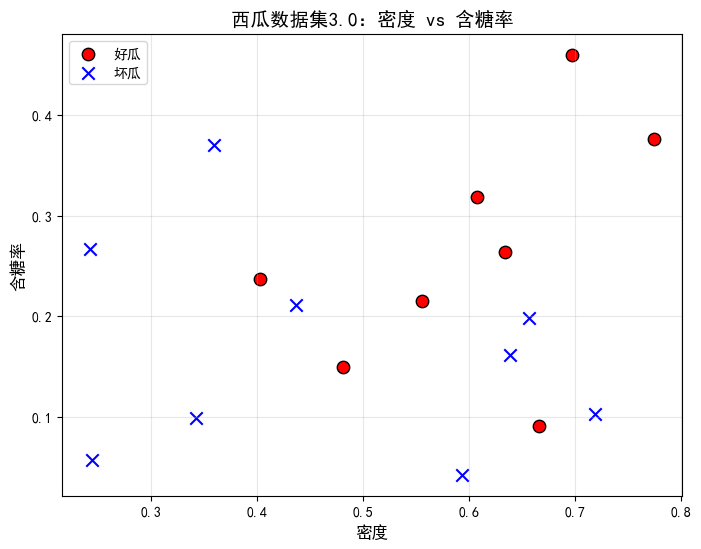

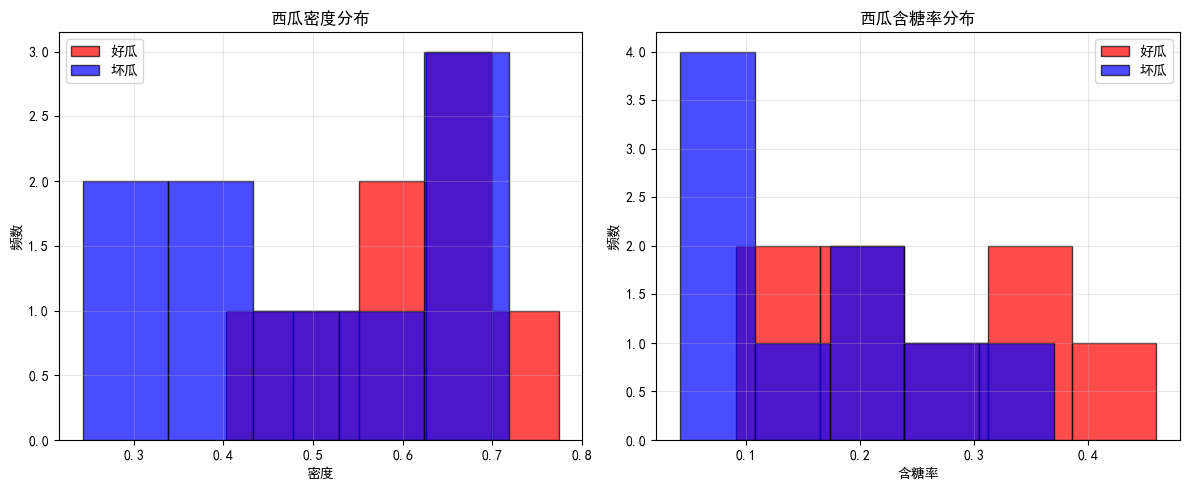

In [ ]:
# %matplotlib inline
plt.rcParams['font.sans-serif'] = ['SimHei']  # 解决中文显示问题
plt.rcParams['axes.unicode_minus'] = False    # 解决负号显示问题

# 提取连续特征和标签（好瓜=1，坏瓜=0）
X_wm3 = df_wm3[['密度', '含糖率']].values
y_wm3 = df_wm3['好瓜'].map({'是':1, '否':0}).values

# 绘制密度-含糖率散点图（颜色区分好瓜/坏瓜）
plt.figure(figsize=(8, 6))
# 绘制好瓜散点
plt.scatter(X_wm3[y_wm3==1, 0], X_wm3[y_wm3==1, 1], 
            color='red', s=80, label='好瓜', marker='o', edgecolor='black')
# 绘制坏瓜散点
plt.scatter(X_wm3[y_wm3==0, 0], X_wm3[y_wm3==0, 1], 
            color='blue', s=80, label='坏瓜', marker='x', edgecolor='black')
# 设置坐标轴和标题
plt.xlabel('密度', fontsize=12)
plt.ylabel('含糖率', fontsize=12)
plt.title('西瓜数据集3.0：密度 vs 含糖率', fontsize=14)
plt.legend(loc='upper left')
plt.grid(alpha=0.3)
plt.show()

# 绘制好瓜/坏瓜的密度、含糖率直方图（对比分布）
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
# 密度直方图
ax1.hist(df_wm3[df_wm3['好瓜']=='是']['密度'], bins=5, alpha=0.7, label='好瓜', color='red', edgecolor='black')
ax1.hist(df_wm3[df_wm3['好瓜']=='否']['密度'], bins=5, alpha=0.7, label='坏瓜', color='blue', edgecolor='black')
ax1.set_xlabel('密度')
ax1.set_ylabel('频数')
ax1.set_title('西瓜密度分布')
ax1.legend()
ax1.grid(alpha=0.3)

# 含糖率直方图
ax2.hist(df_wm3[df_wm3['好瓜']=='是']['含糖率'], bins=5, alpha=0.7, label='好瓜', color='red', edgecolor='black')
ax2.hist(df_wm3[df_wm3['好瓜']=='否']['含糖率'], bins=5, alpha=0.7, label='坏瓜', color='blue', edgecolor='black')
ax2.set_xlabel('含糖率')
ax2.set_ylabel('频数')
ax2.set_title('西瓜含糖率分布')
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [15]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

# 划分特征X和标签y
X = df_wm3.drop('好瓜', axis=1)  # 所有特征（6离散+2连续）
y = df_wm3['好瓜'].map({'是': 1, '否': 0})  # 标签二值化，1=好瓜，0=坏瓜
# 划分训练集（70%）和测试集（30%）
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y  # stratify=y：分层抽样，保证训练/测试集标签分布一致
)
print(f"\n训练集样本数：{X_train.shape[0]}，测试集样本数：{X_test.shape[0]}")
# 定义离散特征和连续特征的列名
cat_features = ['色泽', '根蒂', '敲声', '纹理', '脐部', '触感']  # 离散特征
num_features = ['密度', '含糖率']  # 连续特征

# 构建特征处理器：离散特征独热编码，连续特征不处理
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(sparse_output=False, drop='first'), cat_features),  # drop='first'：避免共线性
        ('num', 'passthrough', num_features)  # 连续特征直接传递
    ]
)
# 查看编码后的特征名称（方便后续分析）
preprocessor.fit(X_train)
cat_feature_names = preprocessor.named_transformers_['cat'].get_feature_names_out(cat_features)
all_feature_names = np.concatenate([cat_feature_names, num_features])
print(f"\n编码后的所有特征名称：")
print(all_feature_names)


训练集样本数：11，测试集样本数：6

编码后的所有特征名称：
['色泽_浅白' '色泽_青绿' '根蒂_稍蜷' '根蒂_蜷缩' '敲声_浊响' '敲声_清脆' '纹理_清晰' '纹理_稍糊' '脐部_平坦'
 '脐部_稍凹' '触感_软粘' '密度' '含糖率']



决策树模型训练完成！

训练集准确率：1.00
测试集准确率：0.50

测试集混淆矩阵：
[[2 1]
 [2 1]]

测试集分类报告：
              precision    recall  f1-score   support

          坏瓜       0.50      0.67      0.57         3
          好瓜       0.50      0.33      0.40         3

    accuracy                           0.50         6
   macro avg       0.50      0.50      0.49         6
weighted avg       0.50      0.50      0.49         6



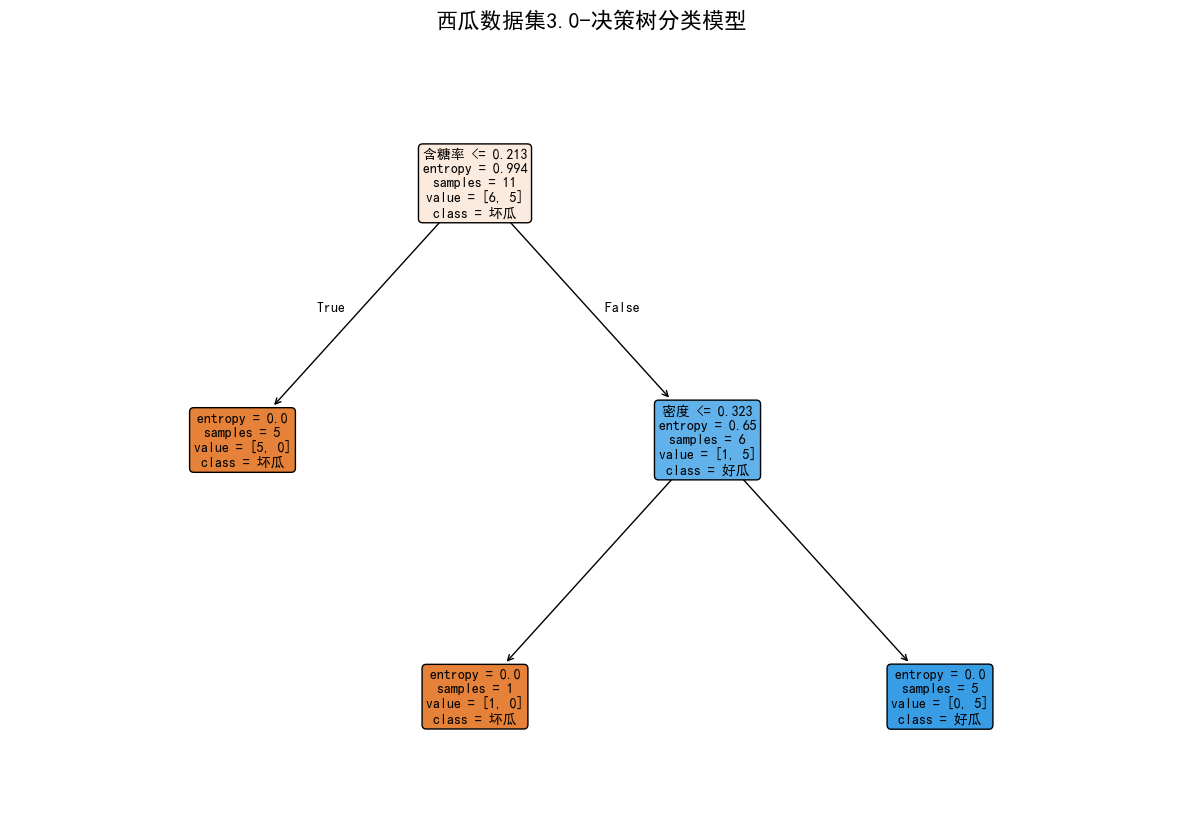

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
# 构建Pipeline：预处理 + 决策树分类器
dt_pipeline = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('classifier', DecisionTreeClassifier(
            criterion='entropy',  # 划分准则：信息熵（可选gini：基尼系数）
            max_depth=3,          # 最大深度，防止过拟合
            random_state=42,
            min_samples_split=2   # 节点划分的最小样本数
        ))
    ]
)
# 训练模型
dt_pipeline.fit(X_train, y_train)
print("\n决策树模型训练完成！")
# 模型预测
y_train_pred = dt_pipeline.predict(X_train)
y_test_pred = dt_pipeline.predict(X_test)
# 1. 准确率评估
train_acc = accuracy_score(y_train, y_train_pred)
test_acc = accuracy_score(y_test, y_test_pred)
print(f"\n训练集准确率：{train_acc:.2f}")
print(f"测试集准确率：{test_acc:.2f}")
# 2. 混淆矩阵（测试集）
cm = confusion_matrix(y_test, y_test_pred)
print(f"\n测试集混淆矩阵：")
print(cm)
# 混淆矩阵解释：
# [[TN, FP],  # TN：坏瓜预测为坏瓜，FP：坏瓜预测为好瓜
#  [FN, TP]]  # FN：好瓜预测为坏瓜，TP：好瓜预测为好瓜
# 3. 分类报告（测试集）：精确率、召回率、F1-score
cr = classification_report(y_test, y_test_pred, target_names=['坏瓜', '好瓜'])
print(f"\n测试集分类报告：")
print(cr)
# 绘制决策树
plt.figure(figsize=(15, 10))
# 提取决策树模型和预处理后的特征名称
dt_model = dt_pipeline.named_steps['classifier']
plot_tree(
    dt_model,
    feature_names=list(all_feature_names),  # 编码后的特征名称
    class_names=['坏瓜', '好瓜'],     # 类别名称
    filled=True,                      # 填充颜色（按类别/信息熵）
    rounded=True,                     # 圆角矩形
    fontsize=10,
    precision=3                       # 数值精度
)
plt.title('西瓜数据集3.0-决策树分类模型', fontsize=16, pad=20)
plt.show()

## 上机内容
1. 安装和配置机器学习开发环境，包括Python、Jupyter Notebook、Numpy、Pandas、Matplotlib。
1. 熟悉Jupyter Notebook、Numpy、Pandas、Matplotlib的使用方法。
1. 结合上述示例代码的加载数据方法，针对鸢尾花数据集（Iris）和糖尿病数据集（Diabetes dataset），查阅其说明文档，了解其特征和标签的含义。
1. 结合上述示例代码的可视化方法，了解如何使用Pandas和Matplotlib进行基本的数据处理与可视化，如查看数据维度、数据类型、统计信息等，观察数据的分布和相关性。
1. （选做）根据可视化结果与课上所教授内容，选择合适的模型和算法进行尝试。
1. （选做）根据教材内容，编写python代码，生成西瓜数据集2.0和3.0，并尝试保存和读取生成的数据集。
1. （选做）使用Matplotlib对西瓜数据集3.0进行可视化分析，观察数据的分布和相关性。
1. 编写报告，总结上机内容的过程和结果，并给出自己的感想和建议。